## S5 - Web Scraping with Python
----

Web scraping is basically a way to use python (or any programming language) to automatically collect information from websites on the internet.

Even if you do not intend to be a heavy python user, this is potentially a useful thing to be introduced to for several reasons


*   It shows you how to collect data from online sources

*   It shows you how easily data can be collected (the challenges of keeping it safe)
*   It introduces you "under the hood" of the internet.


However, unlike the earlier workshops, where the few commands that I show you are basically generally, ***Web Scraping*** is something you have to do from scratch each time because every website is different. Each time you want to scrape a website, you need to customize the web scraping code (and probably build it from scratch). 

The website we will be scraping is : https://reelgood.com/tv/source/netflix

This website posts links about what is availible on netflix. Keep in mind that when scraping, we need to have colab open in one tab, and the website you are scraping in annother.


In [ ]:
# Load Basic Python Packages #

import os 

import pandas as pd
import numpy as np

In [ ]:
# Load Python Packages for Scraping # 

import bs4                               # Beautiful Soup - Package to Parse the HTML Code
import requests                          # Requests - Package to browse the internet with python (url based)

In [ ]:
# Define Website to be scraped #

url_address = "https://reelgood.com/tv/source/netflix"


In [ ]:
# Get the website - This is equivilent to goinginto google chrome, typing in the url, opening up the window and then saving on to your desktop #

scrape_result = requests.get(url_address)

scrape_result

<Response [200]>

This may seem cryptic, but its telling you that the information on the website was collected. 

To get the html from the website we need to run the following command

'<!DOCTYPE html><html lang="en-us"><head><meta charset="utf-8"><meta name="apple-itunes-app" content="app-id=1031391869"><meta name="viewport" content="width=device-width, initial-scale=1.0, maximum-scale=2.0, minimum-scale=1.0"><meta name="apple-itunes-app" content="app-id=1031391869"><meta name="theme-color" content="#091017"><link rel="manifest" href="/manifest.538a5f7752ed93518cd2.json"><meta name="mobile-web-app-capable" content="yes"><meta name="theme-color" content="#081017"><meta name="application-name" content="Reelgood"><link rel="apple-touch-icon" sizes="57x57" href="https://assets.reelgood.com/p/6a2bd6af0b8dfb25c4bf217cf6ea550b3810ef37/icons/apple-touch-icon-57x57.png"><link rel="apple-touch-icon" sizes="60x60" href="https://assets.reelgood.com/p/6a2bd6af0b8dfb25c4bf217cf6ea550b3810ef37/icons/apple-touch-icon-60x60.png"><link rel="apple-touch-icon" sizes="72x72" href="https://assets.reelgood.com/p/6a2bd6af0b8dfb25c4bf217cf6ea550b3810ef37/icons/apple-touch-icon-72x72.png"><l
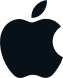
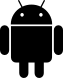

In [ ]:
scrape_result.text

This is how that website looks in html form. This is how the website looks when it is delivered to your browser, and the browser it was what converts it into the visual form you are acustomed to.

If you would like to test this, copy the code above, paste it into a text file and save it on yoru desktop with a suffix .html. Then click on that file an it should open as a website in your browser.


From this point on, we have the HTML on your machine and we are doing everything locally (not accessing the website anymore).

The problem is that while we might visually know how to navigate a website, this format is difficult to read. In order to change that, we are going to use BeautifulSoup.


In [ ]:
soup = bs4.BeautifulSoup(scrape_result.text)

<!DOCTYPE html>
<html lang="en-us"><head><meta charset="utf-8"/><meta content="app-id=1031391869" name="apple-itunes-app"/><meta content="width=device-width, initial-scale=1.0, maximum-scale=2.0, minimum-scale=1.0" name="viewport"/><meta content="app-id=1031391869" name="apple-itunes-app"/><meta content="#091017" name="theme-color"/><link href="/manifest.538a5f7752ed93518cd2.json" rel="manifest"/><meta content="yes" name="mobile-web-app-capable"/><meta content="#081017" name="theme-color"/><meta content="Reelgood" name="application-name"/><link href="https://assets.reelgood.com/p/6a2bd6af0b8dfb25c4bf217cf6ea550b3810ef37/icons/apple-touch-icon-57x57.png" rel="apple-touch-icon" sizes="57x57"/><link href="https://assets.reelgood.com/p/6a2bd6af0b8dfb25c4bf217cf6ea550b3810ef37/icons/apple-touch-icon-60x60.png" rel="apple-touch-icon" sizes="60x60"/><link href="https://assets.reelgood.com/p/6a2bd6af0b8dfb25c4bf217cf6ea550b3810ef37/icons/apple-touch-icon-72x72.png" rel="apple-touch-icon" sizes
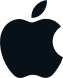
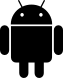

In [ ]:
soup

Already, the output is easiler to parse (things are spaced out and organized) 

What beautiful soup really provides is a clean way for us to search and organize the data table.

You can click on the actual website, in the other tab, and select the inspect option. That will open the HTML explored in the window. From there on, you can see which part of the website is associated with the part of the data you are interested in.

In the case of the netrlix website, each tv show is associated with a <tr> class which contains all of the information. 

In [ ]:
# Note that I'm just running this as code so it gives us the error and you can see the whole syntax # 

<tr itemprop="itemListElement" itemscope="" itemtype="//schema.org/ListItem" class="css-gfsdx9"><td class="css-1n32qfq"><a href="/show/breaking-bad-2008"><div class="css-1rashen e126mwsw1"><picture class="css-b4kcmh e1181ybh0"><source srcset="https://img.reelgood.com/content/show/f75762df-3e5b-4cd3-b621-32399a3dd20d/poster-92.webp 92w,https://img.reelgood.com/content/show/f75762df-3e5b-4cd3-b621-32399a3dd20d/poster-154.webp 154w,https://img.reelgood.com/content/show/f75762df-3e5b-4cd3-b621-32399a3dd20d/poster-185.webp 185w,https://img.reelgood.com/content/show/f75762df-3e5b-4cd3-b621-32399a3dd20d/poster-342.webp 342w" type="image/webp"><source srcset="https://img.reelgood.com/content/show/f75762df-3e5b-4cd3-b621-32399a3dd20d/poster-92.jpg 92w,https://img.reelgood.com/content/show/f75762df-3e5b-4cd3-b621-32399a3dd20d/poster-154.jpg 154w,https://img.reelgood.com/content/show/f75762df-3e5b-4cd3-b621-32399a3dd20d/poster-185.jpg 185w,https://img.reelgood.com/content/show/f75762df-3e5b-4cd3-b621-32399a3dd20d/poster-342.jpg 342w" type="image/jpeg"><img data-async-image="true" src="https://img.reelgood.com/content/show/f75762df-3e5b-4cd3-b621-32399a3dd20d/poster-342.jpg" alt="Breaking Bad Poster" itemprop="image" decoding="async" class="css-4rt6dn e1181ybh1"></picture></div></a></td><td class="css-1u7zfla e126mwsw1"><a href="/show/breaking-bad-2008">Breaking Bad</a><meta itemprop="position" content="0"><meta itemprop="url" content="https://reelgood.com/show/breaking-bad-2008"></td><td class="css-1azbcl6"><span>TV</span></td><td class="css-1u11l3y">2008</td><td class="css-1u11l3y">18+</td><td class="css-1u11l3y"><b class="css-1px39yc"><div class="css-0"><span><b class="css-1px39yc">9.5</b>/10</span></div></b></td><td class="css-1u11l3y"><b class="css-1px39yc"><div><span><b class="css-1px39yc">100</b>/100</span></div></b></td><td class="css-1vuzpp2"><span class="css-1uvh71f"><div class="css-1flk2s8 e11eoopx0"><img src="https://img.reelgood.com/service-logos/netflix.svg" alt="netflix"></div></span><span class="css-1llszt4">+ Rent or Buy</span><span><span class="css-1fmire8"></span></span></td><td class="css-9fnwd0"><div class="css-0">62 <span>Free Episodes</span></div></td><td class="css-1g4hjyy"><div class="css-1bnyegh"><div class="css-1ov9pc1 e126mwsw1"><span>Track</span><img src="data:image/svg+xml;base64,PHN2ZyB4bWxucz0iaHR0cDovL3d3dy53My5vcmcvMjAwMC9zdmciIHdpZHRoPSIxMyIgaGVpZ2h0PSIxMyI+PHBhdGggZD0iTTEyLjU3NS41NzZMLjU3NiA1LjU1OWw1Ljc3MiAxLjI0NCAxLjI0NCA1Ljc3MnoiIGZpbGw9IiNGRkYiIGZpbGwtcnVsZT0iZXZlbm9kZCIvPjwvc3ZnPg==" alt="Tracking Icon" title="Track Show"><div id="trackItPopup" class="css-1iaqbrw e16felo50"><div class="css-5y4ld6 e16felo51">Have You Seen?</div><button data-type="All" class="css-1hknzz6 eyx6tna1">All</button><button data-type="Some" class="css-1hknzz6 eyx6tna1">Some</button><button data-type="None" class="css-1hknzz6 eyx6tna1">None</button><button data-type="cancel" class="css-omf9uz e16felo52">Cancel</button></div></div></div></td></tr>

SyntaxError: ignored

In [ ]:
datarows = soup.find_all('tr',{"class":"css-gfsdx9"})

In [ ]:
FinalOutput  = []

for line in datarows: 

  names = line.find('td', {"class":"css-1u7zfla e126mwsw1"}).text

  url = line.find('meta', {"itemprop":"url"})['content']

  Type = line.find('td', {"class":"css-1azbcl6"}).text

  ReleaseYear = line.find('td', {'class':"css-1u11l3y"}).text
  
  IMDB = line.find('b', {'class':"css-1px39yc"}).text


  Output = [names, url, Type, ReleaseYear, IMDB]

  print(Output)

  FinalOutput.append(Output)

['Breaking Bad', 'https://reelgood.com/show/breaking-bad-2008', 'TV', '2008', '9.5/10']
['Attack on Titan', 'https://reelgood.com/show/attack-on-titan-2013', 'TV', '2013', '8.9/10']
['Stranger Things', 'https://reelgood.com/show/stranger-things-2016', 'TV', '2016', '8.7/10']
['Sherlock', 'https://reelgood.com/show/sherlock-2010', 'TV', '2010', '9.1/10']
['Better Call Saul', 'https://reelgood.com/show/better-call-saul-2015', 'TV', '2015', '8.7/10']
['Dark', 'https://reelgood.com/show/dark-2017', 'TV', '2017', '8.8/10']
["The Queen's Gambit", 'https://reelgood.com/show/the-queens-gambit-2020', 'TV', '2020', '8.6/10']
['Avatar: The Last Airbender', 'https://reelgood.com/show/avatar-the-last-airbender-2005', 'TV', '2005', '9.2/10']
['Peaky Blinders', 'https://reelgood.com/show/peaky-blinders-2013', 'TV', '2013', '8.8/10']
['Black Mirror', 'https://reelgood.com/show/black-mirror-2011', 'TV', '2011', '8.8/10']
['The Walking Dead', 'https://reelgood.com/show/the-walking-dead-2010', 'TV', '201

In [ ]:
PandasData = pd.DataFrame(FinalOutput, columns = ['Name', 'url', 'Type', 'Year', 'IMDB Rating'])

PandasData.head()

,Name,url,Type,Year,IMDB Rating
0,Breaking Bad,https://reelgood.com/show/breaking-bad-2008,TV,2008,9.5/10
1,Attack on Titan,https://reelgood.com/show/attack-on-titan-2013,TV,2013,8.9/10
2,Stranger Things,https://reelgood.com/show/stranger-things-2016,TV,2016,8.7/10
3,Sherlock,https://reelgood.com/show/sherlock-2010,TV,2010,9.1/10
4,Better Call Saul,https://reelgood.com/show/better-call-saul-2015,TV,2015,8.7/10


In [ ]:
# We can also clean up the columns # 

PandasData['IMDB Rating'] = pd.to_numeric(PandasData['IMDB Rating'].replace("/10", ""), errors = 'coerce') 

PandasData.head()

,Name,url,Type,Year,IMDB Rating
0,Breaking Bad,https://reelgood.com/show/breaking-bad-2008,TV,2008,NaN
1,Attack on Titan,https://reelgood.com/show/attack-on-titan-2013,TV,2013,NaN
2,Stranger Things,https://reelgood.com/show/stranger-things-2016,TV,2016,NaN
3,Sherlock,https://reelgood.com/show/sherlock-2010,TV,2010,NaN
4,Better Call Saul,https://reelgood.com/show/better-call-saul-2015,TV,2015,NaN
